In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
# --- Global Constants ---
E_Na = 50.0
E_Ca = 50.0
E_K  = -85.0
E_leak = -10.0
Cm = 1.0

In [3]:
# =====================================================================
# 1. WORKING MYOCARDIUM MODEL (Driven Periodic Activity Train)
# =====================================================================
g_Na = 15.0
g_K_myo = 5.0
g_K1 = 1.2

def alpha_m_na(V): return 1.0 / (1.0 + np.exp(-(V + 40.0) / 5.0))
def alpha_j(V):   return 1.0 / (40.0 * (1.0 + np.exp(-(V + 35.0) / 10.0)))
def beta_j(V):    return 1.0 / (40.0 * (1.0 + np.exp((V + 35.0) / 10.0)))
def x1_inf(V):    return 1.0 / (1.0 + np.exp((V + 75.0) / 8.0))

def working_myocardium_periodic(t, y):
    V, j = y
    
    # Delivers an external pacing pulse of -25 uA for 2 ms, repeating every 150 ms
    t_cycle = t % 150.0
    I_stim = -25.0 if (10.0 <= t_cycle <= 12.0) else 0.0
    
    I_Na = g_Na * (alpha_m_na(V)**3) * (V - E_Na)
    I_K = g_K_myo * j * (V - E_K)
    I_K1 = g_K1 * x1_inf(V) * (V - E_K)
    
    dVdt = -(I_Na + I_K + I_K1 + I_stim) / Cm
    djdt = alpha_j(V) * (1.0 - j) - beta_j(V) * j
    return [dVdt, djdt]

In [4]:
# =====================================================================
# 2. SUSTAINED RHYTHMIC PACEMAKER CELL (Infinite Limit Cycle)
# =====================================================================

g_Ca = 6.0       # Upstroke Calcium conductance
g_K_pace = 5.0   # Balanced Potassium channel density
g_leak = 0.5     # Continuous inward escalator leak driving Phase 4 drift

def pacemaker_cell(t, y):
    V, h, n = y
    
    # Instantaneous L-type Calcium channel activation
    m_ca = 1.0 / (1.0 + np.exp(-(V + 25.0) / 6.0))
    
    I_Ca = g_Ca * m_ca * h * (V - E_Ca)
    I_K = g_K_pace * n * (V - E_K)
    I_leak = g_leak * (V - E_leak)
    
    # Explicit relaxation gating timescales to guarantee continuous rhythmicity
    dhdt = (1.0 / (1.0 + np.exp((V + 40.0) / 8.0)) - h) / 40.0   # tau_h = 40ms
    dndt = (1.0 / (1.0 + np.exp(-(V + 30.0) / 10.0)) - n) / 60.0 # tau_n = 60ms
    
    dVdt = -(I_Ca + I_K + I_leak) / Cm
    return [dVdt, dhdt, dndt]

In [5]:
# =====================================================================
# 3. RUN SIMULATIONS & PLOT RESULTS
# =====================================================================
t_span = (0, 600)  # Extended window to observe 5 full pacemaker cycles
t_eval = np.linspace(t_span[0], t_span[1], 3000)

sol_myo = solve_ivp(working_myocardium_periodic, t_span, [-80.0, 0.1], 
                     t_eval=t_eval, method='BDF', max_step=0.2)

sol_pace = solve_ivp(pacemaker_cell, t_span, [-55.0, 0.6, 0.2], 
                      t_eval=t_eval, method='BDF', max_step=0.2)

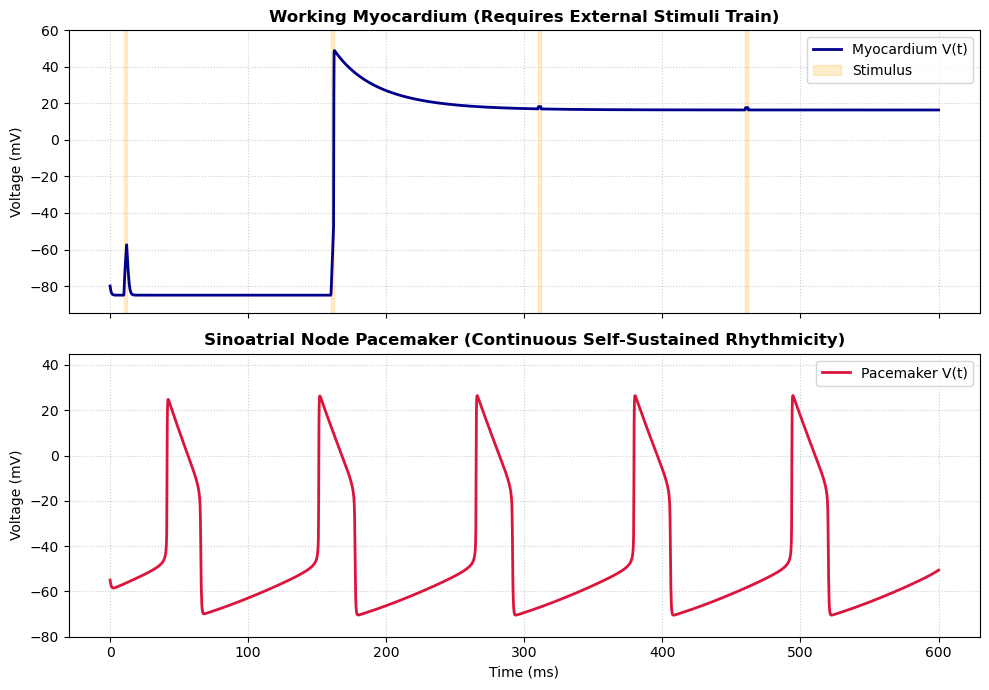

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot(sol_myo.t, sol_myo.y[0], 'darkblue', linewidth=2.0, label='Myocardium V(t)')
for pulse in [10, 160, 310, 460]:
    ax1.axvspan(pulse, pulse + 2, color='orange', alpha=0.2, label='Stimulus' if pulse == 10 else "")
ax1.set_title('Working Myocardium (Requires External Stimuli Train)', fontsize=12, weight='bold')
ax1.set_ylabel('Voltage (mV)')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.set_ylim(-95, 60)
ax1.legend(loc='upper right')

# Bottom Subplot: Sustained Auto-Rhythmic Pacemaker
ax2.plot(sol_pace.t, sol_pace.y[0], 'crimson', linewidth=2.0, label='Pacemaker V(t)')
ax2.set_title('Sinoatrial Node Pacemaker (Continuous Self-Sustained Rhythmicity)', fontsize=12, weight='bold')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Voltage (mV)')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.set_ylim(-80, 45)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()